In [4]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from agents.Classe_agent import Agent
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet
from metrics.metrics import *
from metrics.Classe_model_metrics import ModelMetrics
from synchronize_weight import*
from training.scrpit_generate_agent import genereate_agent
from ExperimentRunner import ExperimentRunner

In [7]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 100

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.version
torch.version.cuda
torch.cuda.is_available()

agent_list = genereate_agent(BATCH_SIZE,N_AGENT,DEVICE)


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775


# Communication Graphe

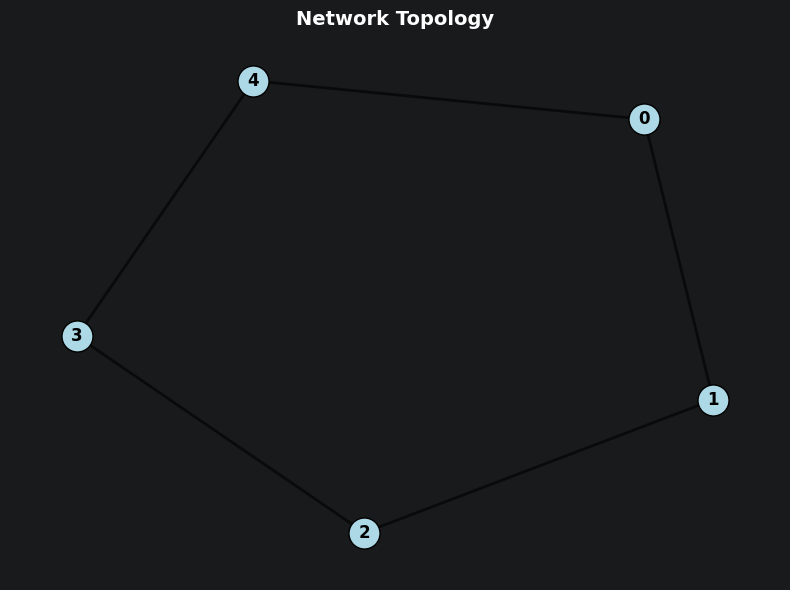

In [8]:
graph = NetworkTopology.cycle_graph(len(agent_list))

for agent_id, agent in enumerate(agent_list):
    graph.add_node(agent_id, agent=agent)

NetworkTopology.visualize_graph(graph)

In [9]:
loss_validate_list = []
accuracy_validate_list = []
metrics = ModelMetrics(agent_list)

for epoch in range(NUM_EPOCHES):

    threads_list = []

    # THREADS
    for agent in agent_list:
        thread = threading.Thread(
            target=agent.train_and_validate,
            args=[agent_list]
        )
        threads_list.append(thread)

    # Start des deux modèles
    for thread in threads_list:
        thread.start()

    print(f"Epoch {epoch+1}/{NUM_EPOCHES}")

    # Attendre la fin
    for thread in threads_list:
        thread.join()

    distances = Agent.node_weight_metric(agent_list)

    for agent, distance in zip(agent_list, distances):
        agent.total_distance_list.append(distance)

    # ============================================
    # Synchronisation des poids
    # ============================================

    #synchronize_models_average(agent_list)
    #synchronize_models_cycle(agent_list)
    consensu_algortyme(agent_list,graph,k)
    #synchronize_with_topology(agent_list,graph)

    metrics.print_all_metrics(epoch)

    metrics.log_metrics(epoch)

print("Les modèles ont fini l'entraînement")

Epoch 1/100
Agent 3 start
Agent 2 start
Agent 4 start
Agent 1 start
Agent 0 start
Model3 - Acc:13.34 % - Loss:2.2916521837711334 %
Model2 - Acc:13.15 % - Loss:2.2940565626621248 %
Model4 - Acc:13.97 % - Loss:2.2946712038516996 %
Model0 - Acc:14.32 % - Loss:2.282241976976395 %
Model1 - Acc:11.89 % - Loss:2.2993288724422456 %
    → Distance moyenne après iter 1: 6.828757
    → Distance moyenne après iter 2: 3.481109
    → Distance moyenne après iter 3: 1.860710
    → Distance moyenne après iter 4: 1.002316
    → Distance moyenne après iter 5: 0.540479

📊 METRICS - Epoch 0

🔹 WEIGHT DISTANCES (Synchronisation)
----------------------------------------------------------------------
  Agent 0:     0.54  
  Agent 1:     0.54  
  Agent 2:     0.54  
  Agent 3:     0.54  
  Agent 4:     0.54  
  Average:      0.54

🔹 PARAMETER VARIANCE
----------------------------------------------------------------------
  conv1.weight                   Var = 0.000005  
  conv1.bias                     Var = 0

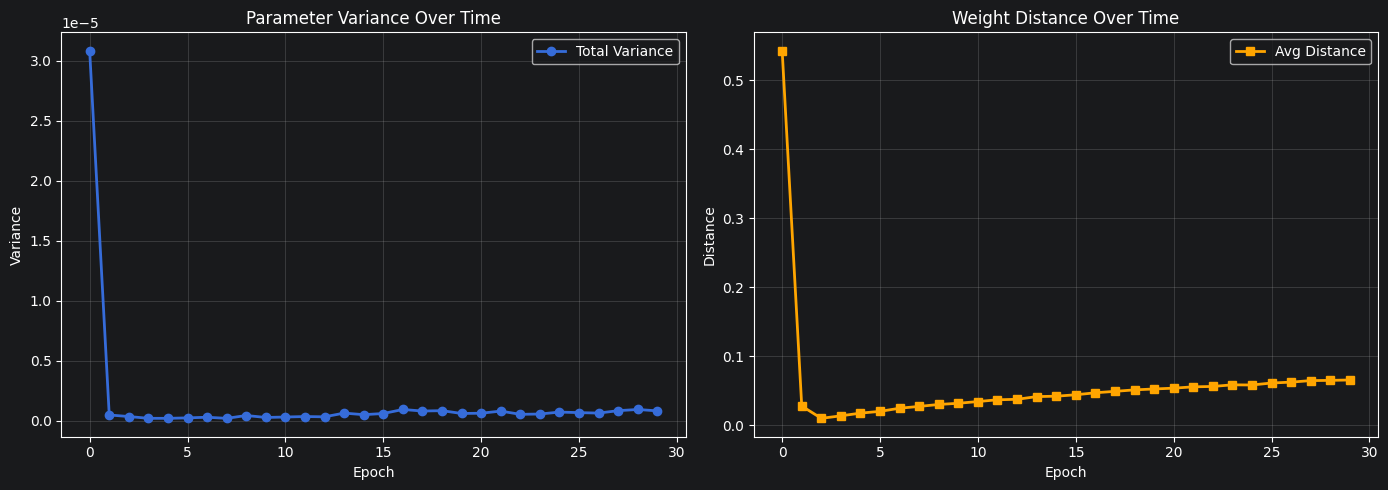

In [6]:
metrics.plot_history()

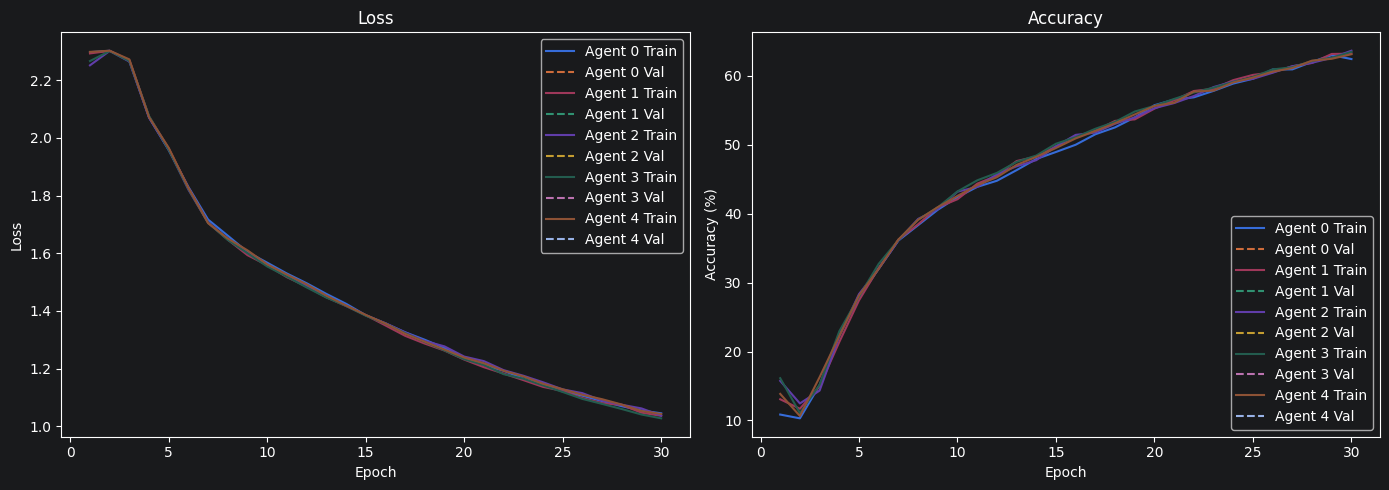

In [7]:
plot_all_agents_metrics(agent_list)

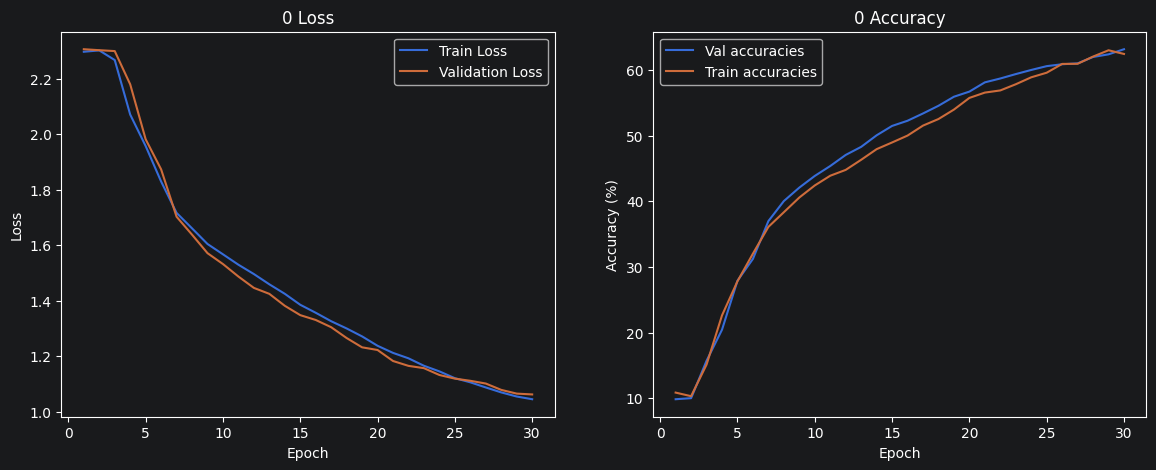

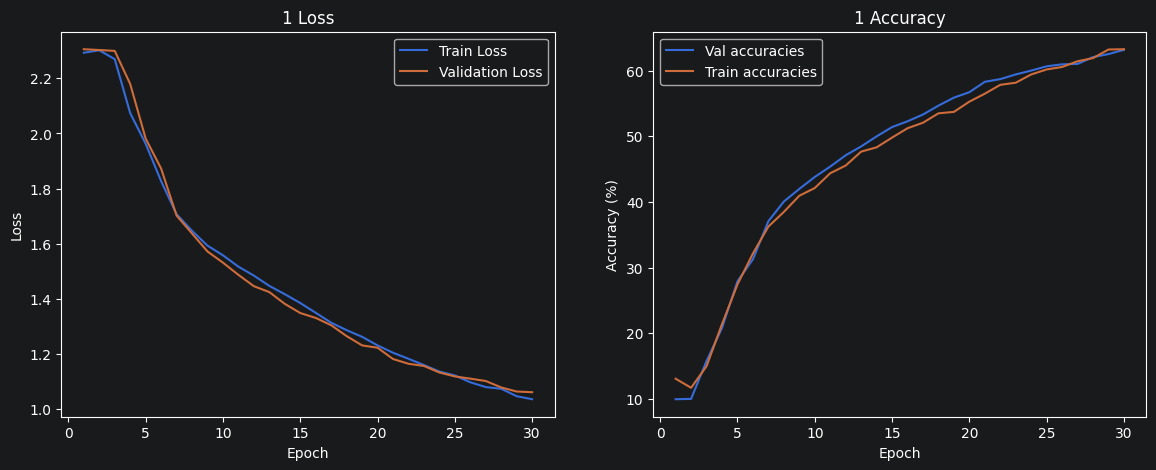

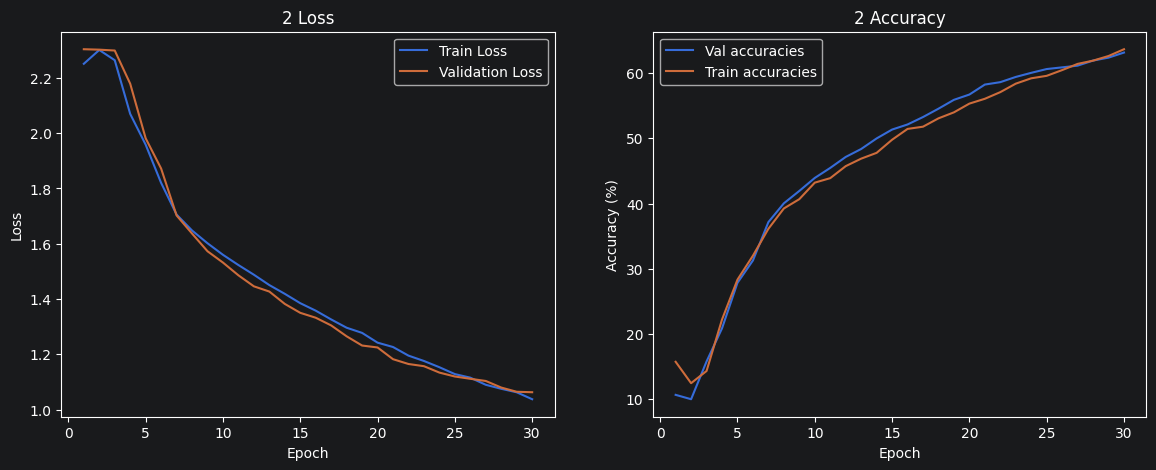

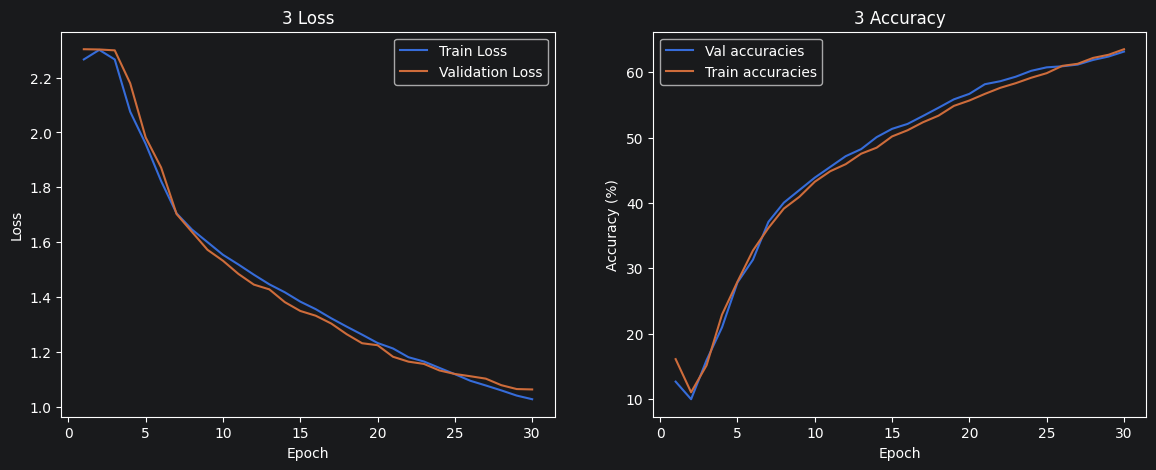

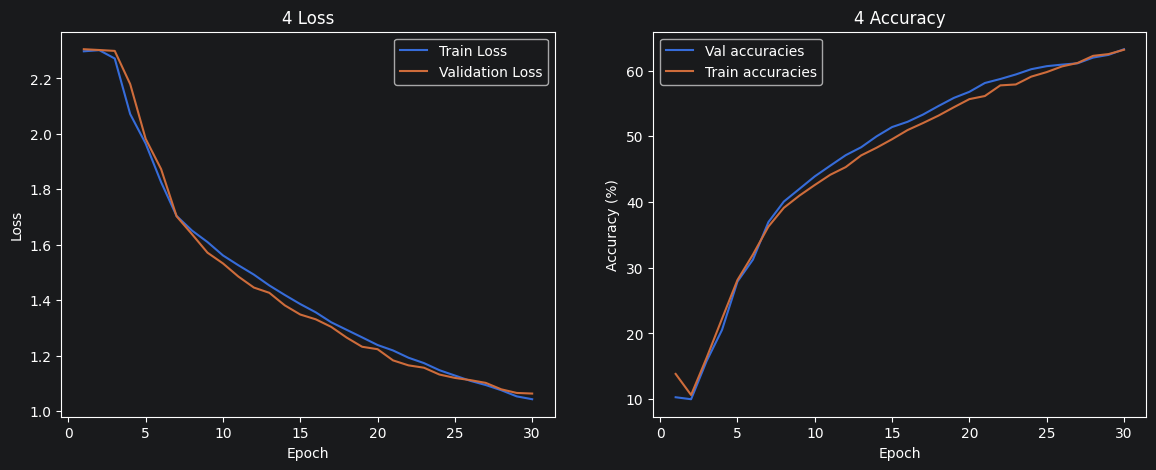

In [9]:
for agent in agent_list:

    agent.plot_metrics()

In [12]:
node_weight_metric(agent_list)


Agent 0
conv1.weight                   L2 distance = 0.003180
conv1.bias                     L2 distance = 0.000908
conv2.weight                   L2 distance = 0.004933
conv2.bias                     L2 distance = 0.000301
fc1.weight                     L2 distance = 0.009778
fc1.bias                       L2 distance = 0.000361
fc2.weight                     L2 distance = 0.004849
fc2.bias                       L2 distance = 0.000488
fc3.weight                     L2 distance = 0.004120
fc3.bias                       L2 distance = 0.000790
Distance totale = 0.029706

Agent 1
conv1.weight                   L2 distance = 0.003435
conv1.bias                     L2 distance = 0.000902
conv2.weight                   L2 distance = 0.005173
conv2.bias                     L2 distance = 0.000231
fc1.weight                     L2 distance = 0.009277
fc1.bias                       L2 distance = 0.000234
fc2.weight                     L2 distance = 0.004454
fc2.bias                       L2 dis

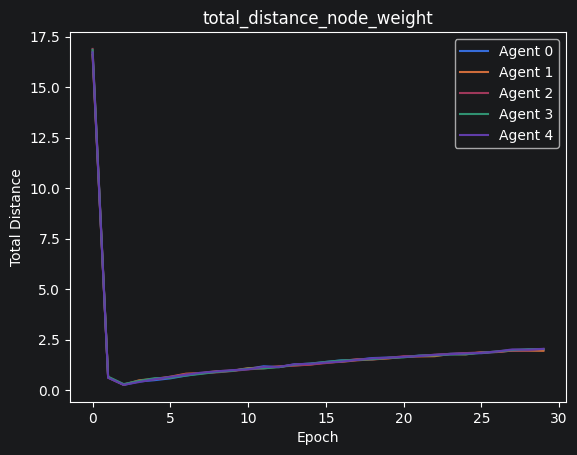

In [10]:
plot_all_agent_node_weight_metric(agent_list)

In [14]:
for agent in agent_list:
    print("Agent",agent.id)
    #print(agent.loss_validate_list)
    print(agent.val_losses)
    #print(agent.accuracy_validate_list)
    print(agent.val_accuracies)

Agent 0
[2.305119649171829, 2.302758082151413, 2.3018102436065675, 2.2947319538593294, 2.1586101331710816, 2.0202702475786207, 1.8904044127464295, 1.789566971898079, 1.6728246143460275, 1.608958977341652]
[10.0, 10.0, 13.29, 15.11, 20.03, 25.44, 30.73, 34.85, 38.71, 40.76]
Agent 1
[2.304589174747467, 2.3027424552440645, 2.301819096326828, 2.2947720589637757, 2.158840028166771, 2.0203251011371615, 1.8902027515172959, 1.7896384028196335, 1.6723584297299385, 1.607698366999626]
[10.0, 10.0, 14.04, 15.07, 20.04, 25.49, 30.93, 34.85, 38.79, 40.84]
Agent 2
[2.3058548002243042, 2.302727950334549, 2.3018116772174837, 2.2946962826251984, 2.158923611998558, 2.0205641169548034, 1.890019845366478, 1.7898259873390199, 1.672233254134655, 1.6052132020592689]
[9.99, 10.0, 13.8, 14.98, 20.02, 25.45, 30.82, 34.92, 38.8, 40.94]
Agent 3
[2.304427543640137, 2.302717181444168, 2.301797329902649, 2.2946089360713957, 2.1587441389560698, 2.0206734281778336, 1.8901250556707383, 1.7898396862745285, 1.672579335570